In [1]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('/home/darashivarani/Desktop/project/backend/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

print(df.shape)
df.head()

(7043, 20)


/tmp/ipykernel_18226/4258830277.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [2]:
from sklearn.preprocessing import StandardScaler

cluster_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

K-Means Silhouette Score: 0.4514


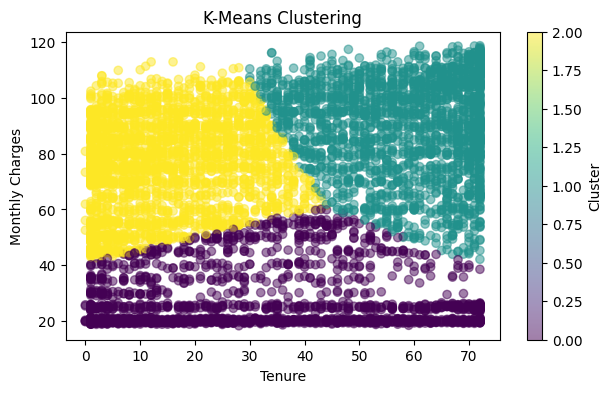

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled)

kmeans_score = silhouette_score(scaled, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

plt.figure(figsize=(7,4))
plt.scatter(df['tenure'], df['MonthlyCharges'], c=kmeans_labels, cmap='viridis', alpha=0.5)
plt.title('K-Means Clustering')
plt.xlabel('Tenure'); plt.ylabel('Monthly Charges')
plt.colorbar(label='Cluster')
plt.show()

Hierarchical Silhouette Score: 0.3960


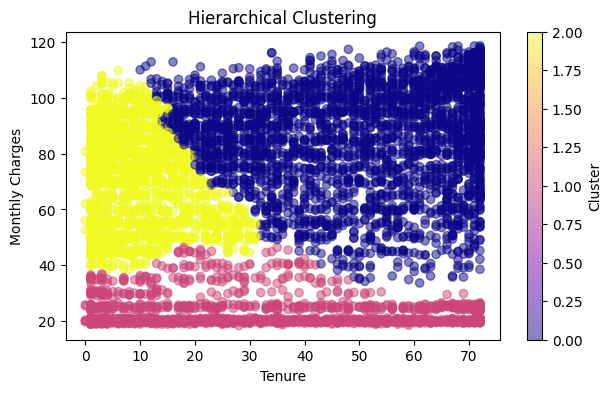

In [4]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(scaled)

hier_score = silhouette_score(scaled, hier_labels)
print(f"Hierarchical Silhouette Score: {hier_score:.4f}")

plt.figure(figsize=(7,4))
plt.scatter(df['tenure'], df['MonthlyCharges'], c=hier_labels, cmap='plasma', alpha=0.5)
plt.title('Hierarchical Clustering')
plt.xlabel('Tenure'); plt.ylabel('Monthly Charges')
plt.colorbar(label='Cluster')
plt.show()

DBSCAN found 1 clusters (label -1 = noise)


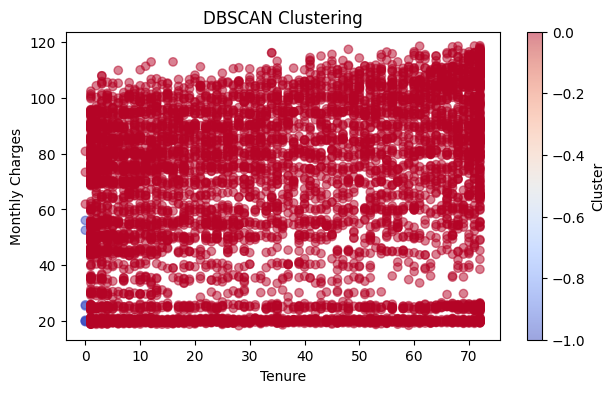

In [5]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled)

# Silhouette score only valid if more than 1 cluster found (ignoring noise label -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN found {n_clusters} clusters (label -1 = noise)")

if n_clusters > 1:
    mask = dbscan_labels != -1
    dbscan_score = silhouette_score(scaled[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_score:.4f}")

plt.figure(figsize=(7,4))
plt.scatter(df['tenure'], df['MonthlyCharges'], c=dbscan_labels, cmap='coolwarm', alpha=0.5)
plt.title('DBSCAN Clustering')
plt.xlabel('Tenure'); plt.ylabel('Monthly Charges')
plt.colorbar(label='Cluster')
plt.show()

In [6]:
print("=" * 40)
print("      CLUSTERING COMPARISON")
print("=" * 40)
print(f"K-Means Silhouette Score     : {kmeans_score:.4f}")
print(f"Hierarchical Silhouette Score: {hier_score:.4f}")
print(f"DBSCAN Clusters Found        : {n_clusters}")
print("=" * 40)
print("Higher silhouette score = better defined clusters")

# Add best clustering result to df
df['Segment'] = kmeans_labels  # change to hier_labels if hierarchical wins

      CLUSTERING COMPARISON
K-Means Silhouette Score     : 0.4514
Hierarchical Silhouette Score: 0.3960
DBSCAN Clusters Found        : 1
Higher silhouette score = better defined clusters


In [7]:
from sklearn.model_selection import train_test_split

# Segment column is already added from K-Means
X = df.drop('Churn', axis=1)  # includes 'Segment' now
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Features used: {list(X.columns)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Features used: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Segment']
Train: (5634, 20), Test: (1409, 20)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("--- Logistic Regression ---")
print(f"Accuracy : {lr_acc:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")
print(classification_report(y_test, lr_pred))

--- Logistic Regression ---
Accuracy : 0.7991
ROC-AUC  : 0.8403
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



/home/darashivarani/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("--- Random Forest ---")
print(f"Accuracy : {rf_acc:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")
print(classification_report(y_test, rf_pred))

--- Random Forest ---
Accuracy : 0.7921
ROC-AUC  : 0.8261
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [10]:
from sklearn.ensemble import GradientBoostingClassifier

xgb = GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("--- Gradient Boosting ---")
print(f"Accuracy : {xgb_acc:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred))

--- Gradient Boosting ---
Accuracy : 0.7878
ROC-AUC  : 0.8257
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



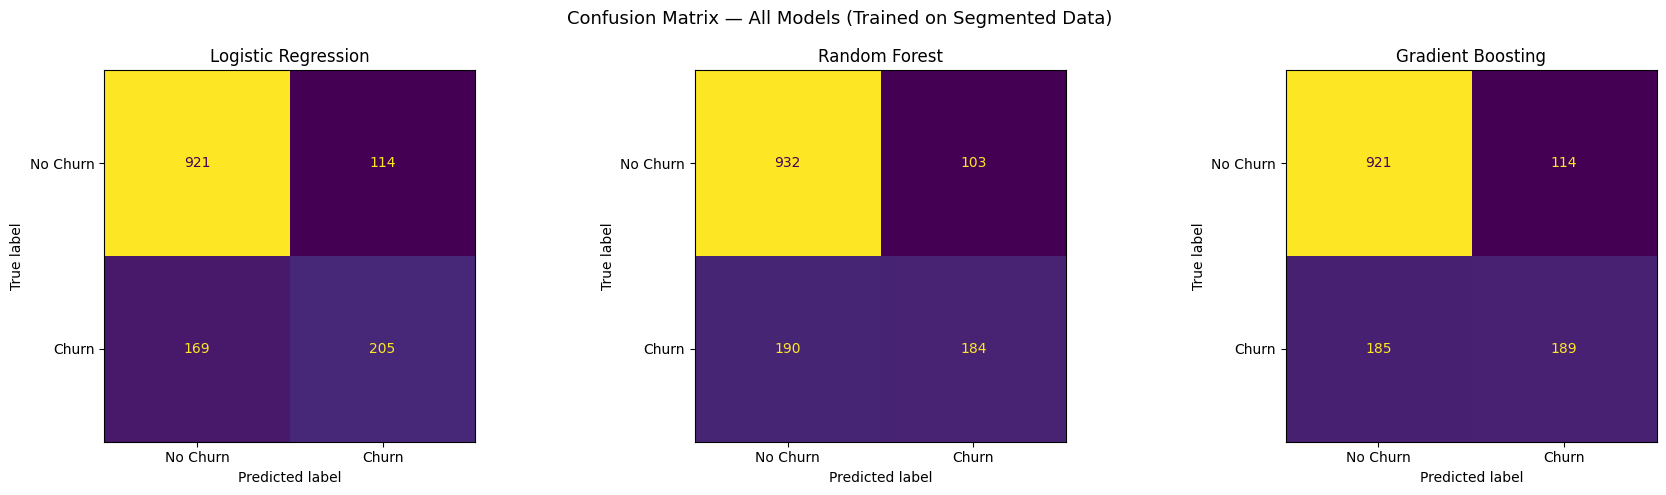

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name in zip(
    axes,
    [lr_pred, rf_pred, xgb_pred],
    ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrix — All Models (Trained on Segmented Data)', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc]
})

print(results.to_string(index=False))
print("\n")

best_model_name = results.loc[results['ROC-AUC'].idxmax(), 'Model']
best_auc = results['ROC-AUC'].max()
print(f"✅ Best Model: {best_model_name} (ROC-AUC: {best_auc:.4f})")

              Model  Accuracy  ROC-AUC
Logistic Regression  0.799148 0.840342
      Random Forest  0.792051 0.826051
  Gradient Boosting  0.787793 0.825701


✅ Best Model: Logistic Regression (ROC-AUC: 0.8403)


/home/darashivarani/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


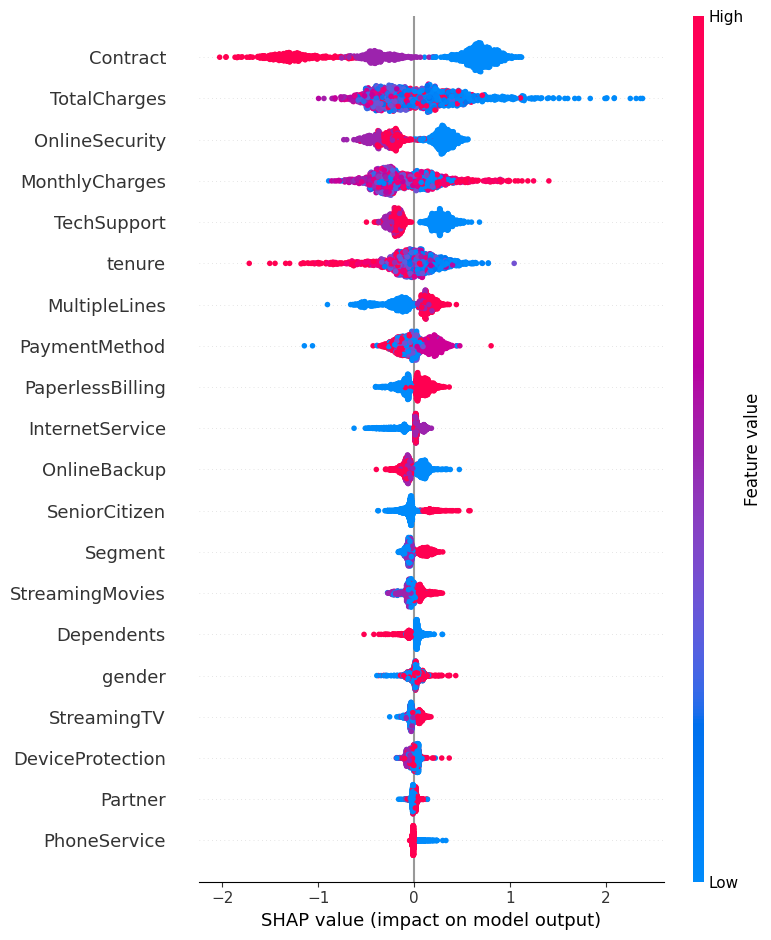

In [13]:
import shap

explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.summary_plot(shap_values, X_test)

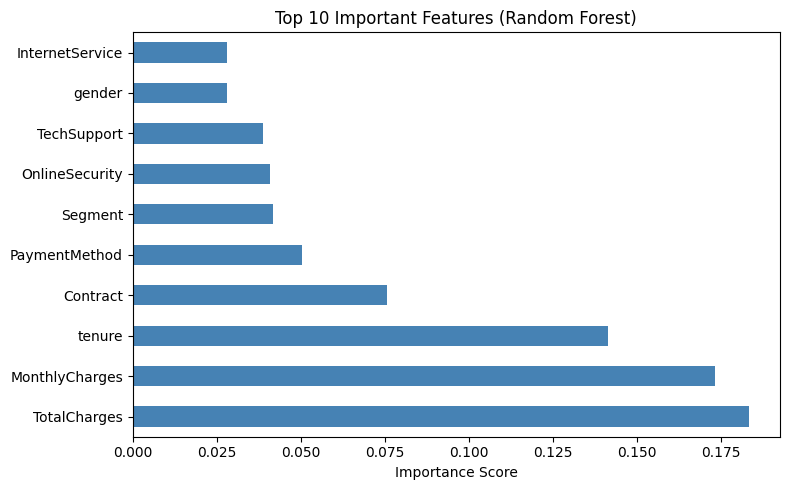

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature Importance from best model
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Top 10 Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [15]:
import joblib

joblib.dump(lr, 'churn_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print("Logistic Regression model saved!")

Logistic Regression model saved!


In [16]:
print('Segment' in X.columns)  # should print True

True


In [17]:
# See the full dataframe with Segment column
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Segment']].head(20)

,tenure,MonthlyCharges,TotalCharges,Churn,Segment
0,1,29.85,29.85,0,0
1,34,56.95,1889.50,0,2
2,2,53.85,108.15,1,2
3,45,42.30,1840.75,0,0
4,2,70.70,151.65,1,2
5,8,99.65,820.50,1,2
6,22,89.10,1949.40,0,2
7,10,29.75,301.90,0,0
8,28,104.80,3046.05,1,2
9,62,56.15,3487.95,0,1


In [18]:
# Segment 0 customers
df[df['Segment'] == 0][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(10)

,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
3,45,42.30,1840.75,0
7,10,29.75,301.90,0
11,16,18.95,326.80,0
16,52,20.65,1022.95,0
20,1,39.65,39.65,1
21,12,19.80,202.25,0
22,1,20.15,20.15,1
27,1,30.20,30.20,1
33,1,20.20,20.20,0


In [19]:
# Segment 1 customers
df[df['Segment'] == 1][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(10)

,tenure,MonthlyCharges,TotalCharges,Churn
9,62,56.15,3487.95,0
12,58,100.35,5681.10,0
13,49,103.70,5036.30,1
15,69,113.25,7895.15,0
17,71,106.70,7382.25,0
23,58,59.90,3505.10,0
24,49,59.60,2970.30,0
26,47,99.35,4749.15,1
28,72,90.25,6369.45,0
30,71,96.35,6766.95,0


In [20]:
# Segment 2 customers
df[df['Segment'] == 2][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(10)

,tenure,MonthlyCharges,TotalCharges,Churn
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
4,2,70.70,151.65,1
5,8,99.65,820.50,1
6,22,89.10,1949.40,0
8,28,104.80,3046.05,1
10,13,49.95,587.45,0
14,25,105.50,2686.05,0
18,10,55.20,528.35,1
19,21,90.05,1862.90,0


In [21]:
!pip install fastapi uvicorn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [22]:
import joblib
feature_names = joblib.load('feature_names.pkl')
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Segment']


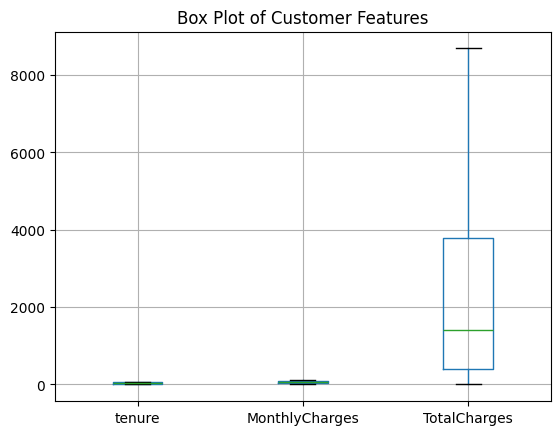

In [23]:
# Box plot for numerical columns
plt.figure()
df[["tenure", "MonthlyCharges", "TotalCharges"]].boxplot()
plt.title("Box Plot of Customer Features")
plt.show()

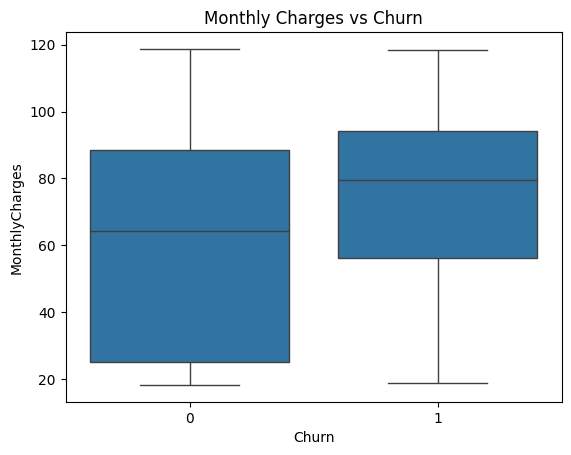

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()